In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


In [20]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# EfficientNetB0 default input size is 224x224
IMG_SIZE = 224

# Load the base model without the top classification layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the pretrained backbone for transfer learning
base_model.trainable = False
print('Base model trainable:', base_model.trainable)
print('Trainable layers in base:', sum(int(l.trainable) for l in base_model.layers), '/', len(base_model.layers))


Base model trainable: False
Trainable layers in base: 0 / 238


In [21]:
df = pd.read_csv('dataset/image_data.csv')

# Drop rows whose image file is missing (prevents tf.io.read_file crashes)
from pathlib import Path
_img_dir = Path('dataset/images')
_exists = df['filename'].astype(str).map(lambda n: (_img_dir / n).exists())
_missing = (~_exists).sum()
if _missing:
    print(f"Warning: dropping {_missing} rows with missing files")
    df = df[_exists].reset_index(drop=True)

# Ensure expected dtypes
df['vehicle_type'] = df['vehicle_type'].astype(str)
df['cope_cage'] = df['cope_cage'].astype(int)
df['destroyed'] = df['destroyed'].astype(int)

print('Rows after cleanup:', len(df))
# df

Rows after cleanup: 130


In [22]:
vehicle_list = sorted(df['vehicle_type'].unique())
num_vehicle_classes = len(vehicle_list)

In [23]:

# Map vehicle string labels to sequential integers (e.g., 'btr' -> 0, 'tank' -> 1)
label_to_index = {name: i for i, name in enumerate(vehicle_list)}
df['vehicle_id'] = df['vehicle_type'].map(label_to_index)

In [24]:
print(f"Detected {num_vehicle_classes} unique vehicle classes: {vehicle_list}")


Detected 2 unique vehicle classes: ['btr', 'tank']


In [25]:
# --- Build + compile multi-head model ---

# GlobalAveragePooling is typically better than Flatten for transfer learning
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

type_head = layers.Dense(num_vehicle_classes, activation='softmax', name='type_output_layer')(x)
cage_head = layers.Dense(1, activation='sigmoid', name='cage_output_layer')(x)
status_head = layers.Dense(1, activation='sigmoid', name='status_output_layer')(x)

model = models.Model(inputs=base_model.input, outputs=[type_head, cage_head, status_head])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={
        'type_output_layer': tf.keras.losses.SparseCategoricalCrossentropy(),
        'cage_output_layer': tf.keras.losses.BinaryCrossentropy(),
        'status_output_layer': tf.keras.losses.BinaryCrossentropy(),
    },
    metrics={
        'type_output_layer': 'accuracy',
        'cage_output_layer': 'accuracy',
        'status_output_layer': 'accuracy',
    },
)

print('Built + compiled model with num_vehicle_classes =', num_vehicle_classes)
print('Backbone:', base_model.name, 'Input:', model.input_shape)


Built + compiled model with num_vehicle_classes = 2
Backbone: efficientnetb0 Input: (None, 224, 224, 3)


In [26]:
def process_path(filename, vehicle_id, cope_cage, destroyed):
    """Load + decode image, resize to IMG_SIZE, and return labels for multi-head training."""
    # Ensure filename is a scalar string tensor (some pipelines can introduce extra dims)
    filename = tf.reshape(tf.squeeze(filename), [])
    tf.debugging.assert_rank(filename, 0, message='filename must be scalar')
    img_path = tf.strings.join(['dataset/images/', filename])
    tf.debugging.assert_rank(img_path, 0, message='img_path must be scalar')

    # Read bytes
    img_bytes = tf.io.read_file(img_path)
    tf.debugging.assert_rank(img_bytes, 0, message='img_bytes must be scalar')

    # Decode to a fixed 3-channel RGB tensor (handles JPEG/PNG/WEBP, etc.)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])

    # Resize to the backbone input size
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    # EfficientNetB0 (with built-in preprocessing) expects float inputs in [0, 255]
    img = tf.cast(img, tf.float32)

    return img, {
        'type_output_layer': tf.cast(vehicle_id, tf.int32),
        'cage_output_layer': tf.cast(cope_cage, tf.float32),
        'status_output_layer': tf.cast(destroyed, tf.float32),
    }


In [27]:
# --- Stratified train/validation split (combined key: vehicle_type|cope_cage|destroyed) ---

SEED = 42
VAL_FRAC = 0.20

rng = np.random.RandomState(SEED)

strat_key = (
    df["vehicle_type"].astype(str)
    + "|c" + df["cope_cage"].astype(int).astype(str)
    + "|d" + df["destroyed"].astype(int).astype(str)
)

print("Stratum counts (vehicle_type|cope_cage|destroyed):")
display(strat_key.value_counts())

train_indices = []
val_indices = []

for key, group in df.groupby(strat_key):
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    n = len(idx)

    n_val = int(round(n * VAL_FRAC))
    if n >= 2:
        n_val = min(max(1, n_val), n - 1)
    else:
        # Can't split a singleton stratum; keep it in train.
        n_val = 0

    val_indices.extend(idx[:n_val].tolist())
    train_indices.extend(idx[n_val:].tolist())

train_df = df.loc[train_indices].sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = df.loc[val_indices].sample(frac=1, random_state=SEED).reset_index(drop=True)

if len(val_df) == 0 or len(train_df) == 0:
    raise ValueError(f"Invalid split produced. train={len(train_df)} val={len(val_df)}")

print(f"\nSplit sizes: train={len(train_df)}  val={len(val_df)}  (val_frac={len(val_df)/len(df):.3f})")
print("Validation combined-key counts:")
display((val_df["vehicle_type"].astype(str)
         + "|c" + val_df["cope_cage"].astype(int).astype(str)
         + "|d" + val_df["destroyed"].astype(int).astype(str)).value_counts())

# --- Train Generator ---
train_dataset = tf.data.Dataset.from_tensor_slices((
    train_df['filename'].values,
    train_df['vehicle_id'].values,
    train_df['cope_cage'].values,
    train_df['destroyed'].values,
))
train_generator = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

# --- Validation Generator ---
val_dataset = tf.data.Dataset.from_tensor_slices((
    val_df['filename'].values,
    val_df['vehicle_id'].values,
    val_df['cope_cage'].values,
    val_df['destroyed'].values,
))
val_generator = val_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)


Stratum counts (vehicle_type|cope_cage|destroyed):


btr|c0|d0     31
tank|c1|d0    24
tank|c0|d0    23
btr|c0|d1     21
tank|c0|d1    18
btr|c1|d0     10
tank|c1|d1     2
btr|c1|d1      1
Name: count, dtype: int64


Split sizes: train=103  val=27  (val_frac=0.208)
Validation combined-key counts:


btr|c0|d0     6
tank|c0|d0    5
tank|c1|d0    5
btr|c0|d1     4
tank|c0|d1    4
btr|c1|d0     2
tank|c1|d1    1
Name: count, dtype: int64

In [28]:
# --- Inspect val_dataset / val_generator ---

# 1) Inspect the underlying validation DataFrame

display(val_df[["filename", "vehicle_type", "vehicle_id", "cope_cage", "destroyed"]])
print("VALUE COUNTS:")
print(val_df["vehicle_type"].value_counts())
print(val_df["cope_cage"].value_counts())
print(val_df["destroyed"].value_counts())

# 2) Inspect the tf.data signatures

print("val_dataset.element_spec:")
print(val_dataset.element_spec)

print("\nval_generator.element_spec (after process_path + batching):")
print(val_generator.element_spec)

# 3) Preview a few raw (unprocessed) items from val_dataset
preview = []
for filename, vehicle_id, cope_cage, destroyed in val_dataset.take(10):
    fn = filename.numpy()
    if isinstance(fn, (bytes, bytearray)):
        fn = fn.decode("utf-8")
    vid = int(vehicle_id.numpy())
    preview.append({
        "filename": str(fn),
        "vehicle_id": vid,
        "vehicle_type": vehicle_list[vid] if 0 <= vid < len(vehicle_list) else None,
        "cope_cage": int(cope_cage.numpy()),
        "destroyed": int(destroyed.numpy()),
    })

display(pd.DataFrame(preview))

# 4) Preview a processed batch from val_generator
images, labels = next(iter(val_generator.take(1)))
print("\nProcessed batch shapes:")
print("images:", images.shape)
print("labels keys:", list(labels.keys()))
for k, v in labels.items():
    print(f"{k}: {v.shape}")


,filename,vehicle_type,vehicle_id,cope_cage,destroyed
0,btr42.jpeg,btr,0,0,1
1,tank49.jpeg,tank,1,0,0
2,btr45.jpeg,btr,0,0,1
3,tank60.jpeg,tank,1,1,0
4,btr59.jpeg,btr,0,0,0
5,btr22.jpeg,btr,0,1,0
6,tank47.jpeg,tank,1,0,0
7,tank20.jpeg,tank,1,0,1
8,tank23.jpeg,tank,1,0,0
9,tank5.jpeg,tank,1,1,0


VALUE COUNTS:
vehicle_type
tank    15
btr     12
Name: count, dtype: int64
cope_cage
0    19
1     8
Name: count, dtype: int64
destroyed
0    18
1     9
Name: count, dtype: int64
val_dataset.element_spec:
(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))

val_generator.element_spec (after process_path + batching):
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'type_output_layer': TensorSpec(shape=(None,), dtype=tf.int32, name=None), 'cage_output_layer': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'status_output_layer': TensorSpec(shape=(None,), dtype=tf.float32, name=None)})


,filename,vehicle_id,vehicle_type,cope_cage,destroyed
0,btr42.jpeg,0,btr,0,1
1,tank49.jpeg,1,tank,0,0
2,btr45.jpeg,0,btr,0,1
3,tank60.jpeg,1,tank,1,0
4,btr59.jpeg,0,btr,0,0
5,btr22.jpeg,0,btr,1,0
6,tank47.jpeg,1,tank,0,0
7,tank20.jpeg,1,tank,0,1
8,tank23.jpeg,1,tank,0,0
9,tank5.jpeg,1,tank,1,0



Processed batch shapes:
images: (27, 224, 224, 3)
labels keys: ['type_output_layer', 'cage_output_layer', 'status_output_layer']
type_output_layer: (27,)
cage_output_layer: (27,)
status_output_layer: (27,)


In [11]:
# --- Train model on stratified holdout split ---
# Phase 1: train heads with frozen backbone
# Phase 2: fine-tune top EfficientNet layers with a lower learning rate

EPOCHS = 20
FROZEN_EPOCHS = 15
FINE_TUNE_EPOCHS = EPOCHS - FROZEN_EPOCHS

print(f"Starting training pipeline (frozen backbone) for {FROZEN_EPOCHS} epochs...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FROZEN_EPOCHS,
)

# --- Fine-tuning: unfreeze the top layers of the backbone ---
FINE_TUNE_LAYERS = 30  # unfreeze the last N layers (keep BatchNorm frozen)
print(f"\nStarting fine-tuning: unfreezing last {FINE_TUNE_LAYERS} backbone layers (BatchNorm kept frozen)...")

base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        'type_output_layer': tf.keras.losses.SparseCategoricalCrossentropy(),
        'cage_output_layer': tf.keras.losses.BinaryCrossentropy(),
        'status_output_layer': tf.keras.losses.BinaryCrossentropy(),
    },
    metrics={
        'type_output_layer': 'accuracy',
        'cage_output_layer': 'accuracy',
        'status_output_layer': 'accuracy',
    },
)

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    initial_epoch=FROZEN_EPOCHS,
    epochs=FROZEN_EPOCHS + FINE_TUNE_EPOCHS,
)

# Merge histories so downstream plots/metrics work unchanged
for k, v in history_ft.history.items():
    history.history.setdefault(k, []).extend(v)

print("Training complete!")


Starting training pipeline (frozen backbone) for 15 epochs...
Epoch 1/15


W0000 00:00:1780943772.851773   25169 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.
W0000 00:00:1780943772.893740   25169 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.
W0000 00:00:1780943772.936451   25169 cpu_allocator_impl.cc:82] Allocation of 156905472 exceeds 10% of free system memory.


1/4 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - cage_output_layer_accuracy: 0.3125 - cage_output_layer_loss: 0.7573 - loss: 2.2572 - status_output_layer_accuracy: 0.6562 - status_output_layer_loss: 0.6370 - type_output_layer_accuracy: 0.3750 - type_output_layer_loss: 0.8628

W0000 00:00:1780943773.444659   25163 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.
W0000 00:00:1780943773.489212   25163 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - cage_output_layer_accuracy: 0.4563 - cage_output_layer_loss: 0.6999 - loss: 2.1613 - status_output_layer_accuracy: 0.5825 - status_output_layer_loss: 0.6417 - type_output_layer_accuracy: 0.4175 - type_output_layer_loss: 0.7519 - val_cage_output_layer_accuracy: 0.6296 - val_cage_output_layer_loss: 0.6741 - val_loss: 2.0055 - val_status_output_layer_accuracy: 0.6667 - val_status_output_layer_loss: 0.6334 - val_type_output_layer_accuracy: 0.4444 - val_type_output_layer_loss: 0.6980
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 593ms/step - cage_output_layer_accuracy: 0.5340 - cage_output_layer_loss: 0.7035 - loss: 2.0988 - status_output_layer_accuracy: 0.6602 - status_output_layer_loss: 0.6271 - type_output_layer_accuracy: 0.4466 - type_output_layer_loss: 0.7480 - val_cage_output_layer_accuracy: 0.7037 - val_cage_output_layer_loss: 0.6341 - val_loss: 1.9220 - val_status_output_layer_accuracy: 0.6667 - val_status_output_layer_loss: 0.6188 - val_type_output_l

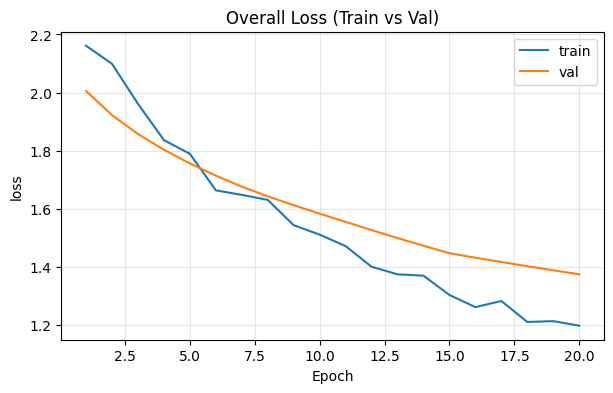

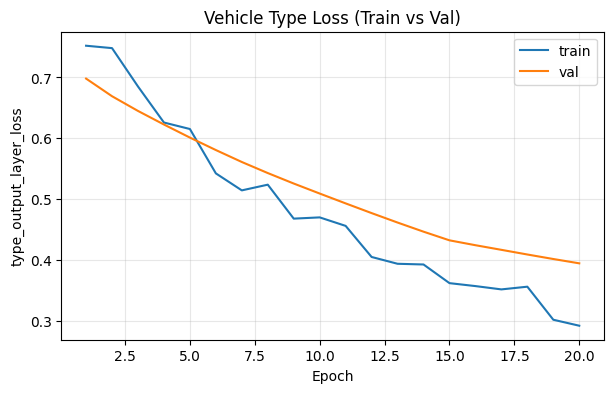

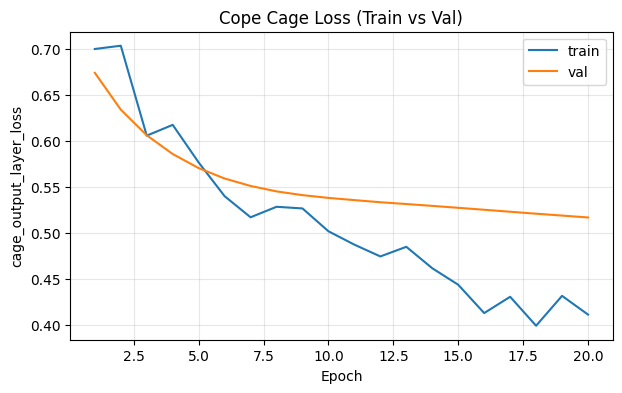

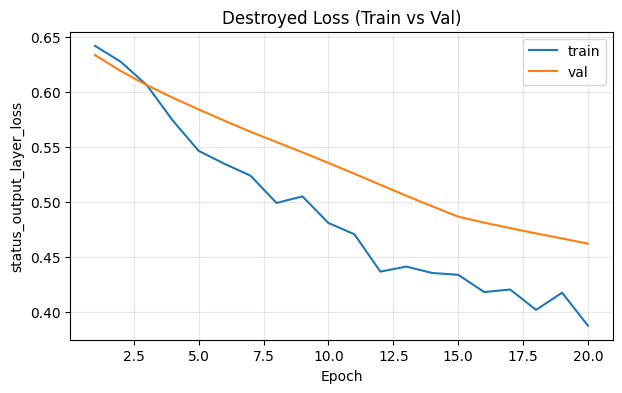

In [12]:
# --- Visualisations: total + per-head loss curves (train vs val) ---

hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

def plot_train_vs_val(key: str, title: str = None):
    train_key = key
    val_key = f"val_{key}"
    if train_key not in hist or val_key not in hist:
        print(f"Missing keys: {train_key!r} or {val_key!r}. Available keys: {list(hist.keys())}")
        return

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, hist[train_key], label="train")
    plt.plot(epochs, hist[val_key], label="val")
    plt.xlabel("Epoch")
    plt.ylabel(key)
    plt.title(title or f"Train vs Val: {key}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Overall combined loss (sum of the 3 head losses)
plot_train_vs_val("loss", "Overall Loss (Train vs Val)")

# Per-head losses
plot_train_vs_val("type_output_layer_loss", "Vehicle Type Loss (Train vs Val)")
plot_train_vs_val("cage_output_layer_loss", "Cope Cage Loss (Train vs Val)")
plot_train_vs_val("status_output_layer_loss", "Destroyed Loss (Train vs Val)")


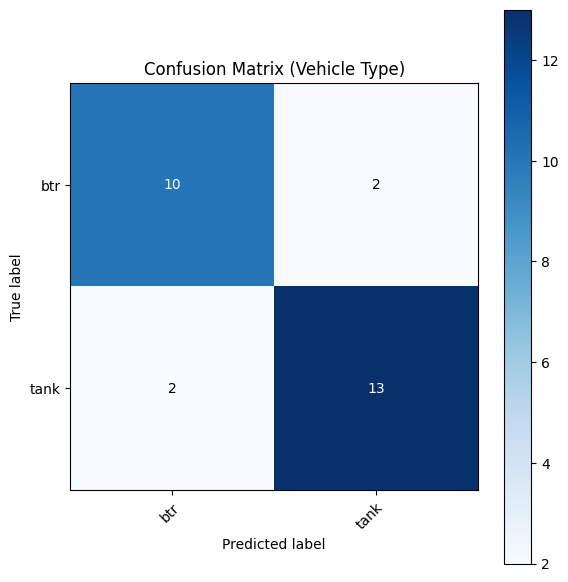

In [13]:
# --- Confusion matrix for vehicle type (type_output_layer) on the validation set ---

# Collect true labels
type_true = []
for _, y in val_generator:
    type_true.append(y['type_output_layer'].numpy())
type_true = np.concatenate(type_true, axis=0)

# Predict
preds = model.predict(val_generator, verbose=0)
if isinstance(preds, (list, tuple)):
    type_probs = preds[0]
elif isinstance(preds, dict):
    type_probs = preds['type_output_layer']
else:
    raise TypeError(f'Unexpected predict output type: {type(preds)}')

type_pred = np.argmax(type_probs, axis=1)
cm = tf.math.confusion_matrix(type_true, type_pred, num_classes=num_vehicle_classes).numpy()

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(num_vehicle_classes),
    yticks=np.arange(num_vehicle_classes),
    xticklabels=vehicle_list,
    yticklabels=vehicle_list,
    xlabel='Predicted label',
    ylabel='True label',
    title='Confusion Matrix (Vehicle Type)'
)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Write counts in each cell
threshold = cm.max() / 2.0 if cm.max() else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

fig.tight_layout()
plt.show()


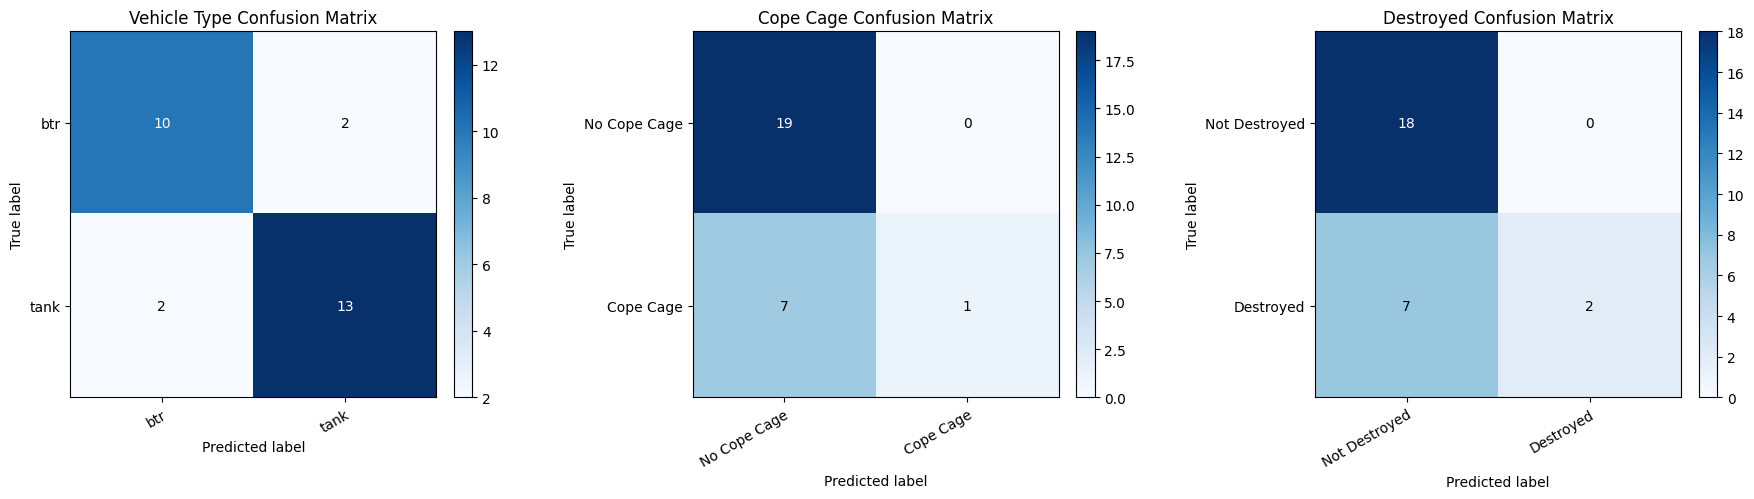

In [14]:
# --- Confusion matrices for all three heads on the validation set ---

# Recompute labels + predictions here so this cell is self-contained.
_type_true = []
_cage_true = []
_status_true = []

for _, y in val_generator:
    _type_true.append(y['type_output_layer'].numpy())
    _cage_true.append(y['cage_output_layer'].numpy())
    _status_true.append(y['status_output_layer'].numpy())

_type_true = np.concatenate(_type_true, axis=0).reshape(-1)
_cage_true = np.concatenate(_cage_true, axis=0).reshape(-1).astype(int)
_status_true = np.concatenate(_status_true, axis=0).reshape(-1).astype(int)

_preds = model.predict(val_generator, verbose=0)
if isinstance(_preds, (list, tuple)):
    _type_probs, _cage_prob, _status_prob = _preds
elif isinstance(_preds, dict):
    _type_probs = _preds['type_output_layer']
    _cage_prob = _preds['cage_output_layer']
    _status_prob = _preds['status_output_layer']
else:
    raise TypeError(f'Unexpected predict output type: {type(_preds)}')

_type_pred = np.argmax(np.asarray(_type_probs), axis=1).reshape(-1)
_cage_pred = (np.asarray(_cage_prob).reshape(-1) >= 0.5).astype(int)
_status_pred = (np.asarray(_status_prob).reshape(-1) >= 0.5).astype(int)

cm_specs = [
    (
        tf.math.confusion_matrix(_type_true, _type_pred, num_classes=num_vehicle_classes).numpy(),
        vehicle_list,
        'Vehicle Type Confusion Matrix',
    ),
    (
        tf.math.confusion_matrix(_cage_true, _cage_pred, num_classes=2).numpy(),
        ['No Cope Cage', 'Cope Cage'],
        'Cope Cage Confusion Matrix',
    ),
    (
        tf.math.confusion_matrix(_status_true, _status_pred, num_classes=2).numpy(),
        ['Not Destroyed', 'Destroyed'],
        'Destroyed Confusion Matrix',
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (cm, labels, title) in zip(axes, cm_specs):
    im = ax.imshow(cm, cmap='Blues')
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel='Predicted label',
        ylabel='True label',
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')

    threshold = cm.max() / 2.0 if cm.size and cm.max() else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                int(cm[i, j]),
                ha='center',
                va='center',
                color='white' if cm[i, j] > threshold else 'black',
            )

fig.tight_layout()
plt.show()

In [15]:
# --- Metrics helpers (accuracy / precision / recall / F1) ---

def _safe_div(numer: float, denom: float) -> float:
    return float(numer) / float(denom) if denom else 0.0

def binary_metrics_from_probs(y_true, y_prob, threshold: float = 0.5):
    """Compute binary accuracy/precision/recall/F1 given true labels and predicted probabilities."""
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    accuracy = _safe_div(tp + tn, tp + tn + fp + fn)
    precision = _safe_div(tp, tp + fp)
    recall = _safe_div(tp, tp + fn)
    f1 = _safe_div(2 * precision * recall, precision + recall) if (precision + recall) else 0.0

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "threshold": float(threshold),
        "support": int(tp + tn + fp + fn),
    }

def multiclass_metrics_from_cm(cm: np.ndarray, class_names):
    """Per-class precision/recall/F1 + overall accuracy from a confusion matrix."""
    cm = np.asarray(cm, dtype=np.int64)
    class_names = list(class_names)

    total = int(cm.sum())
    correct = int(np.trace(cm))
    overall_acc = _safe_div(correct, total)

    per_rows = []
    supports = cm.sum(axis=1)
    preds = cm.sum(axis=0)

    for i, name in enumerate(class_names):
        tp = int(cm[i, i])
        fp = int(preds[i] - tp)
        fn = int(supports[i] - tp)
        precision = _safe_div(tp, tp + fp)
        recall = _safe_div(tp, tp + fn)
        f1 = _safe_div(2 * precision * recall, precision + recall) if (precision + recall) else 0.0
        per_rows.append({"class": name, "support": int(supports[i]), "precision": precision, "recall": recall, "f1": f1})

    per_df = pd.DataFrame(per_rows)
    macro = per_df[["precision", "recall", "f1"]].mean(numeric_only=True)
    weights = per_df["support"].to_numpy()
    weighted = (per_df[["precision", "recall", "f1"]].to_numpy() * weights[:, None]).sum(axis=0) / max(1, weights.sum())

    summary_df = pd.DataFrame(
        [
            {"avg": "overall", "accuracy": overall_acc, "precision": np.nan, "recall": np.nan, "f1": np.nan, "support": total},
            {"avg": "macro", "accuracy": np.nan, "precision": float(macro["precision"]), "recall": float(macro["recall"]), "f1": float(macro["f1"]), "support": total},
            {"avg": "weighted", "accuracy": np.nan, "precision": float(weighted[0]), "recall": float(weighted[1]), "f1": float(weighted[2]), "support": total},
        ]
    )

    return per_df, summary_df


In [16]:
# --- Compute metrics on the validation set for each head ---

# Collect true labels from the validation generator
_type_true = []
_cage_true = []
_status_true = []

for _, y in val_generator:
    _type_true.append(y["type_output_layer"].numpy())
    _cage_true.append(y["cage_output_layer"].numpy())
    _status_true.append(y["status_output_layer"].numpy())

_type_true = np.concatenate(_type_true, axis=0).reshape(-1)
_cage_true = np.concatenate(_cage_true, axis=0).reshape(-1)
_status_true = np.concatenate(_status_true, axis=0).reshape(-1)

# Predict probabilities for all heads
_preds = model.predict(val_generator, verbose=0)
if isinstance(_preds, (list, tuple)):
    _type_probs, _cage_prob, _status_prob = _preds
elif isinstance(_preds, dict):
    _type_probs = _preds["type_output_layer"]
    _cage_prob = _preds["cage_output_layer"]
    _status_prob = _preds["status_output_layer"]
else:
    raise TypeError(f"Unexpected predict output type: {type(_preds)}")

_type_probs = np.asarray(_type_probs)
_cage_prob = np.asarray(_cage_prob).reshape(-1)
_status_prob = np.asarray(_status_prob).reshape(-1)

# 1) Vehicle type head (multi-class)
_type_pred = np.argmax(_type_probs, axis=1).reshape(-1)
_cm_type = tf.math.confusion_matrix(_type_true, _type_pred, num_classes=num_vehicle_classes).numpy()

per_class_df, summary_df = multiclass_metrics_from_cm(_cm_type, vehicle_list)
print("Vehicle type head metrics (from confusion matrix)")
display(per_class_df)
display(summary_df)

# 2) Binary heads (cope cage + destroyed)
THRESHOLD = 0.5
rows = []
rows.append({"head": "cage_output_layer", **binary_metrics_from_probs(_cage_true, _cage_prob, threshold=THRESHOLD)})
rows.append({"head": "status_output_layer", **binary_metrics_from_probs(_status_true, _status_prob, threshold=THRESHOLD)})

bin_df = pd.DataFrame(rows)
print(f"Binary heads metrics (threshold={THRESHOLD})")
display(bin_df[["head", "accuracy", "precision", "recall", "f1", "tp", "tn", "fp", "fn", "support"]])


Vehicle type head metrics (from confusion matrix)


,class,support,precision,recall,f1
0,btr,12,0.833333,0.833333,0.833333
1,tank,15,0.866667,0.866667,0.866667


,avg,accuracy,precision,recall,f1,support
0,overall,0.851852,NaN,NaN,NaN,27
1,macro,NaN,0.850000,0.850000,0.850000,27
2,weighted,NaN,0.851852,0.851852,0.851852,27


Binary heads metrics (threshold=0.5)


,head,accuracy,precision,recall,f1,tp,tn,fp,fn,support
0,cage_output_layer,0.740741,1.0,0.125000,0.222222,1,19,0,7,27
1,status_output_layer,0.740741,1.0,0.222222,0.363636,2,18,0,7,27


In [30]:
# --- Comparison table for all three classifiers ---

type_per_class_df, type_summary_df = multiclass_metrics_from_cm(_cm_type, vehicle_list)
cage_metrics = binary_metrics_from_probs(_cage_true, _cage_prob, threshold=0.5)
status_metrics = binary_metrics_from_probs(_status_true, _status_prob, threshold=0.5)

comparison_df = pd.DataFrame([
    {
        'classifier': 'vehicle_type',
        'accuracy': float(type_summary_df.loc[type_summary_df['avg'] == 'overall', 'accuracy'].iloc[0]),
        'precision': float(type_summary_df.loc[type_summary_df['avg'] == 'macro', 'precision'].iloc[0]),
        'recall': float(type_summary_df.loc[type_summary_df['avg'] == 'macro', 'recall'].iloc[0]),
        'f1': float(type_summary_df.loc[type_summary_df['avg'] == 'macro', 'f1'].iloc[0]),
        'support': int(type_summary_df.loc[type_summary_df['avg'] == 'overall', 'support'].iloc[0]),
    },
    {
        'classifier': 'cope_cage',
        'accuracy': float(cage_metrics['accuracy']),
        'precision': float(cage_metrics['precision']),
        'recall': float(cage_metrics['recall']),
        'f1': float(cage_metrics['f1']),
        'support': int(cage_metrics['support']),
    },
    {
        'classifier': 'destroyed',
        'accuracy': float(status_metrics['accuracy']),
        'precision': float(status_metrics['precision']),
        'recall': float(status_metrics['recall']),
        'f1': float(status_metrics['f1']),
        'support': int(status_metrics['support']),
    },
])

display(comparison_df.round(4))

,classifier,accuracy,precision,recall,f1,support
0,vehicle_type,0.8519,0.85,0.8500,0.8500,27
1,cope_cage,0.7407,1.00,0.1250,0.2222,27
2,destroyed,0.7407,1.00,0.2222,0.3636,27


In [17]:
# --- Threshold tuning / probability investigation ---
# Binary heads: choose probability cutoffs to trade precision vs recall
# Type head: inspect softmax confidence (max prob) to support agent wording thresholds

thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)


def threshold_sweep_binary(y_true, y_prob, head_name: str):
    rows = []
    for t in thresholds:
        m = binary_metrics_from_probs(y_true, y_prob, threshold=float(t))
        rows.append({"head": head_name, **m})
    sweep_df = pd.DataFrame(rows)

    # Best threshold by F1 (common default when you want balance)
    best_f1_row = sweep_df.loc[sweep_df["f1"].idxmax()].to_dict()

    # Best threshold by recall subject to decent precision (avoid spamming false positives)
    min_precision = 0.8
    feasible = sweep_df[sweep_df["precision"] >= min_precision]
    if len(feasible):
        best_recall_row = feasible.loc[feasible["recall"].idxmax()].to_dict()
    else:
        best_recall_row = None

    return sweep_df, best_f1_row, best_recall_row


def sweep_softmax_confidence(type_true, type_probs, class_names):
    """Investigate max-softmax confidence for multiclass predictions.

    This does NOT change the predicted class (argmax). It helps you pick agent wording thresholds
    like 'could be' / 'is likely' / 'is' based on how accurate the model is at different
    confidence levels.
    """
    type_true = np.asarray(type_true).reshape(-1)
    type_probs = np.asarray(type_probs)

    type_pred = np.argmax(type_probs, axis=1).reshape(-1)
    type_conf = np.max(type_probs, axis=1).reshape(-1)
    correct = (type_pred == type_true)

    rows = []
    n_total = int(len(type_true))
    for t in thresholds:
        mask = type_conf >= float(t)
        n_cov = int(np.sum(mask))
        cov = n_cov / n_total if n_total else 0.0
        acc_cov = float(np.mean(correct[mask])) if n_cov else np.nan
        rows.append({
            "threshold": float(t),
            "coverage": cov,
            "accuracy_on_covered": acc_cov,
            "n_covered": n_cov,
            "n_total": n_total,
        })

    sweep_df = pd.DataFrame(rows)

    # Helpful summary stats for confidence distribution
    quantiles = np.quantile(type_conf, [0.0, 0.25, 0.5, 0.75, 1.0]) if n_total else np.array([])
    quantile_df = pd.DataFrame(
        {
            "q": ["min", "25%", "50%", "75%", "max"],
            "type_conf": quantiles,
        }
    )

    # Show the most/least confident predictions to sanity-check
    idx_sorted = np.argsort(type_conf)
    k = min(10, n_total)
    low_idx = idx_sorted[:k]
    high_idx = idx_sorted[-k:][::-1]

    def _preview(indices, title):
        prev = []
        for i in indices:
            pred_name = class_names[int(type_pred[i])] if 0 <= int(type_pred[i]) < len(class_names) else str(int(type_pred[i]))
            true_name = class_names[int(type_true[i])] if 0 <= int(type_true[i]) < len(class_names) else str(int(type_true[i]))
            prev.append({
                "i": int(i),
                "true": true_name,
                "pred": pred_name,
                "conf": float(type_conf[i]),
                "correct": bool(correct[i]),
            })
        print(title)
        display(pd.DataFrame(prev))

    return sweep_df, quantile_df, (low_idx, high_idx), _preview


# -----------------
# Binary heads sweep
# -----------------
print("Binary heads: imbalance check + naive baseline")
for name, y in [("cope_cage", _cage_true), ("destroyed", _status_true)]:
    pos_rate = float(np.mean(np.asarray(y).reshape(-1)))
    baseline_acc = max(pos_rate, 1.0 - pos_rate)  # always-predict-majority baseline
    print(f"{name}: pos_rate={pos_rate:.3f}  majority-class baseline accuracy={baseline_acc:.3f}")

cage_sweep_df, cage_best_f1, cage_best_recall = threshold_sweep_binary(_cage_true, _cage_prob, "cage_output_layer")
status_sweep_df, status_best_f1, status_best_recall = threshold_sweep_binary(_status_true, _status_prob, "status_output_layer")

print("\nCope cage threshold sweep (key columns)")
display(cage_sweep_df[["threshold", "accuracy", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]])
print("Best by F1:", {k: cage_best_f1[k] for k in ["threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]})
if cage_best_recall is not None:
    print("Best recall with precision>=0.8:", {k: cage_best_recall[k] for k in ["threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]})

print("\nDestroyed threshold sweep (key columns)")
display(status_sweep_df[["threshold", "accuracy", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]])
print("Best by F1:", {k: status_best_f1[k] for k in ["threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]})
if status_best_recall is not None:
    print("Best recall with precision>=0.8:", {k: status_best_recall[k] for k in ["threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]})


# ----------------------------
# Type head probability sweep
# ----------------------------
print("\nVehicle type head: softmax confidence investigation")

# Uses variables computed in the previous metrics cell: _type_true, _type_probs
# (If you re-run out of order, run the metrics cell first.)

type_conf_sweep_df, type_conf_quantiles_df, (low_idx, high_idx), _preview = sweep_softmax_confidence(
    _type_true, _type_probs, vehicle_list
)

print("Type confidence quantiles (max softmax probability)")
display(type_conf_quantiles_df)

print("\nType confidence sweep: if we only say 'is' above threshold")
display(type_conf_sweep_df)

_preview(low_idx, "\nLeast confident type predictions")
_preview(high_idx, "\nMost confident type predictions")

# Optional: example wording bands (edit these in your frontend agent)
TYPE_T_LIKELY = 0.60
TYPE_T_IS = 0.80
print(f"\nExample wording thresholds for TYPE: likely={TYPE_T_LIKELY:.2f}, is={TYPE_T_IS:.2f}")
print("Interpretation: conf < likely -> 'could be'; likely<=conf<is -> 'is likely'; conf>=is -> 'is'")


Binary heads: imbalance check + naive baseline
cope_cage: pos_rate=0.296  majority-class baseline accuracy=0.704
destroyed: pos_rate=0.333  majority-class baseline accuracy=0.667

Cope cage threshold sweep (key columns)


,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn
0,0.05,0.296296,0.296296,1.000,0.457143,8,19,0,0
1,0.10,0.296296,0.296296,1.000,0.457143,8,19,0,0
2,0.15,0.296296,0.296296,1.000,0.457143,8,19,0,0
3,0.20,0.481481,0.333333,0.750,0.461538,6,12,2,7
4,0.25,0.666667,0.461538,0.750,0.571429,6,7,2,12
5,0.30,0.814815,0.666667,0.750,0.705882,6,3,2,16
6,0.35,0.777778,0.666667,0.500,0.571429,4,2,4,17
7,0.40,0.777778,0.750000,0.375,0.500000,3,1,5,18
8,0.45,0.814815,1.000000,0.375,0.545455,3,0,5,19
9,0.50,0.740741,1.000000,0.125,0.222222,1,0,7,19


Best by F1: {'threshold': 0.3, 'precision': 0.6666666666666666, 'recall': 0.75, 'f1': 0.7058823529411765, 'tp': 6, 'fp': 3, 'fn': 2, 'tn': 16}
Best recall with precision>=0.8: {'threshold': 0.45, 'precision': 1.0, 'recall': 0.375, 'f1': 0.5454545454545454, 'tp': 3, 'fp': 0, 'fn': 5, 'tn': 19}

Destroyed threshold sweep (key columns)


,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn
0,0.05,0.333333,0.333333,1.000000,0.500000,9,18,0,0
1,0.10,0.333333,0.333333,1.000000,0.500000,9,18,0,0
2,0.15,0.407407,0.360000,1.000000,0.529412,9,16,0,2
3,0.20,0.555556,0.428571,1.000000,0.600000,9,12,0,6
4,0.25,0.740741,0.562500,1.000000,0.720000,9,7,0,11
5,0.30,0.851852,0.727273,0.888889,0.800000,8,3,1,15
6,0.35,0.888889,0.800000,0.888889,0.842105,8,2,1,16
7,0.40,0.888889,0.875000,0.777778,0.823529,7,1,2,17
8,0.45,0.814815,0.833333,0.555556,0.666667,5,1,4,17
9,0.50,0.740741,1.000000,0.222222,0.363636,2,0,7,18


Best by F1: {'threshold': 0.35, 'precision': 0.8, 'recall': 0.8888888888888888, 'f1': 0.8421052631578948, 'tp': 8, 'fp': 2, 'fn': 1, 'tn': 16}
Best recall with precision>=0.8: {'threshold': 0.35, 'precision': 0.8, 'recall': 0.8888888888888888, 'f1': 0.8421052631578948, 'tp': 8, 'fp': 2, 'fn': 1, 'tn': 16}

Vehicle type head: softmax confidence investigation
Type confidence quantiles (max softmax probability)


...


Least confident type predictions


,i,true,pred,conf,correct
0,15,tank,btr,0.533156,False
1,6,tank,tank,0.554181,True
2,23,btr,tank,0.559723,False
3,4,btr,btr,0.563447,True
4,2,btr,btr,0.564947,True
5,14,tank,btr,0.565200,False
6,0,btr,tank,0.596750,False
7,18,tank,tank,0.632852,True
8,1,tank,tank,0.651761,True
9,5,btr,btr,0.659116,True



Most confident type predictions


,i,true,pred,conf,correct
0,21,tank,tank,0.937852,True
1,8,tank,tank,0.884502,True
2,19,tank,tank,0.856003,True
3,10,btr,btr,0.834774,True
4,12,btr,btr,0.831371,True
5,13,btr,btr,0.799647,True
6,25,tank,tank,0.796808,True
7,3,tank,tank,0.782769,True
8,24,tank,tank,0.781053,True
9,20,tank,tank,0.776758,True



Example wording thresholds for TYPE: likely=0.60, is=0.80
Interpretation: conf < likely -> 'could be'; likely<=conf<is -> 'is likely'; conf>=is -> 'is'


In [18]:
import json
from pathlib import Path

legacy_export_dir = Path("converted_keras")
legacy_export_dir.mkdir(parents=True, exist_ok=True)

legacy_model_path = legacy_export_dir / "model_2.h5"
legacy_labels_path = legacy_export_dir / "labels.txt"

backend_export_dir = Path("../exported_model")
backend_export_dir.mkdir(parents=True, exist_ok=True)

backend_model_path = backend_export_dir / "model_2.keras"
backend_meta_path = backend_export_dir / "metadata.json"

model.save(legacy_model_path)
model.save(backend_model_path)

label_lines = [
    "0 vehicle_type\n",
    *[f"{index + 1} {name}\n" for index, name in enumerate(vehicle_list)],
    f"{len(vehicle_list) + 1} cope_cage\n",
    f"{len(vehicle_list) + 2} destroyed\n",
]
legacy_labels_path.write_text("".join(label_lines), encoding="utf-8")

metadata = {
    "img_size": int(IMG_SIZE),
    "vehicle_list": list(vehicle_list),
    "thresholds": {
        "type_likely": float(TYPE_T_LIKELY),
        "type_is": float(TYPE_T_IS),
        "cope_cage": float(cage_best_f1["threshold"]),
        "destroyed": float(status_best_f1["threshold"]),
    },
}
backend_meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved backend model to {backend_model_path.resolve()}")
print(f"Saved backend metadata to {backend_meta_path.resolve()}")
print(f"Saved legacy model to {legacy_model_path.resolve()}")
print(f"Saved legacy labels to {legacy_labels_path.resolve()}")

Saved backend model to /home/jack_merriman/Desktop/projects/AAI-2/exported_model/model_2.keras
Saved backend metadata to /home/jack_merriman/Desktop/projects/AAI-2/exported_model/metadata.json
Saved legacy model to /home/jack_merriman/Desktop/projects/AAI-2/Model/converted_keras/model_2.h5
Saved legacy labels to /home/jack_merriman/Desktop/projects/AAI-2/Model/converted_keras/labels.txt
